# Exercise E3

This notebook produces the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [2]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# Exercise 1: South Pole

Text(0.5, 1.0, 'The Antarctic Continent and the Southern Ocean starting from 60°S')

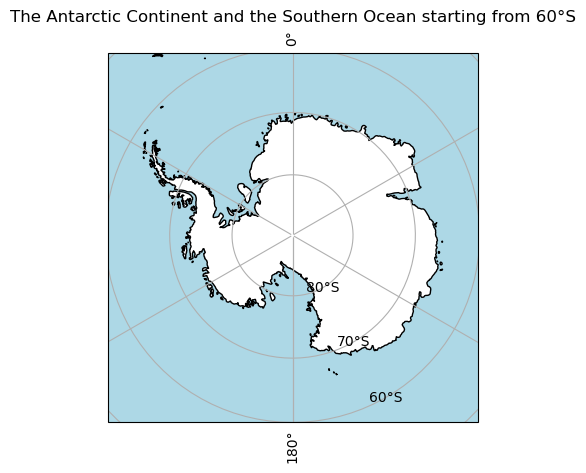

In [2]:
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.coastlines()


ax.add_feature(cfeature.LAND, facecolor='white')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
gl = ax.gridlines(draw_labels=True)
        
plt.title("The Antarctic Continent and the Southern Ocean starting from 60°S")




In [8]:
geolocator = Nominatim(user_agent='educational') 

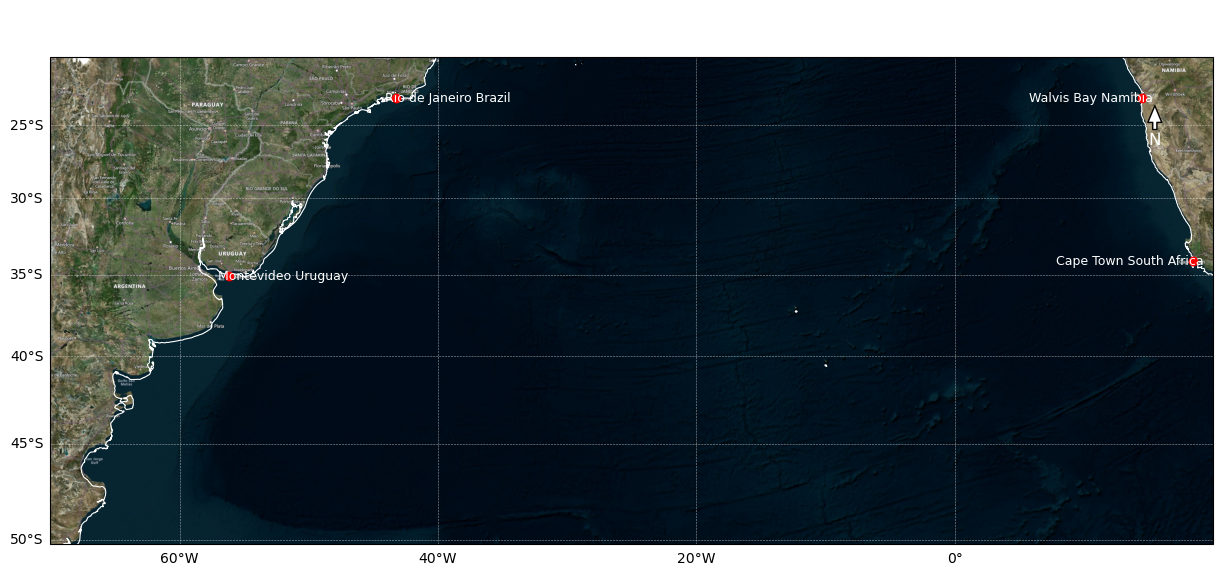

In [17]:
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

# SOUTH ATLANTIC EXTENT
extent = [-70, 20, -50, -20]

# Cities
places = [
    'Walvis Bay Namibia',
    'Cape Town South Africa',
    'Rio de Janeiro Brazil',
    'Montevideo Uruguay'
]

geolocator = Nominatim(user_agent='educational')
locations = [geolocator.geocode(p) for p in places]

# ESRI WORLD IMAGERY (SATELLITE)
class ESRIWorldImagery(cimgt.QuadtreeTiles):
    def __init__(self):
        super().__init__(
            'https://server.arcgisonline.com/ArcGIS/rest/services/'
            'World_Imagery/MapServer/tile/{z}/{y}/{x}.jpg'
        )
        
        self.desired_tile_form = 'RGB'

tiler = ESRIWorldImagery()

# FIGURE
plt.figure(figsize=(15, 7))

# ✅ IMPORTANT: use the tile provider's native projection
ax = plt.axes(projection=tiler.crs)

ax.set_extent(extent, crs=ccrs.PlateCarree())

# Zoom level: 6–7 is ideal for regional basins
ax.add_image(tiler, 6)

# OVERLAYS
ax.coastlines(resolution='10m', linewidth=0.8, color='white')

gl = ax.gridlines(draw_labels=True,
                  linewidth=0.4,
                  color='white',
                  alpha=0.6,
                  linestyle='--')
gl.top_labels = False
gl.right_labels = False

# PLOT CITIES
for place, loc in zip(places, locations):
    ax.plot(loc.longitude,
            loc.latitude,
            'ro',
            markersize=6,
            transform=ccrs.PlateCarree())
    

    if loc.longitude < -20:
        offset = (-8, 0)
        ha = 'left'
    else:
        offset = (8, 0)
        ha = 'right'


    ax.annotate(
        place,
        xy=(loc.longitude, loc.latitude),
        xycoords=ccrs.PlateCarree(),
        xytext=offset,
        textcoords='offset points',
        color='white',
        fontsize=9,
        ha= ha,
        va='center'
    )


# NORTH ARROW
ax.annotate(
    "N",
    xy=(0.95, 0.9),
    xytext=(0.95, 0.83),
    xycoords=ax.transAxes,
    arrowprops=dict(facecolor="white", width=3, headwidth=10),
    ha="center",
    va="center",
    fontsize=12,
    color='white'
)

plt.title(
    "South Atlantic Ocean (20°S–50°S)\nSatellite Imagery (ESRI World Imagery)",
    fontsize=15,
    color='white'
)

plt.show()